# Company Data Preprocessing for Customer Segmentation

This notebook combines all company data sources and applies best-practice preprocessing for ML clustering.

**Data Sources:**
- Internal features: RFM metrics, product mix, operations complexity
- Companies House: Basic profile, officers, filings, charges
- Web presence: Website detection results

**Strategy:** Median imputation with missing indicators (recommended for clustering with MAR data)

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Sklearn imports
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))
from scripts.preprocessing_custom import FrequencyEncoder, TargetEncoder

## 1. Load All Data Sources

In [2]:
# Paths
DATA_DIR = Path('../data/companies')

# Load all datasets
df_main = pd.read_csv(DATA_DIR / 'company_features.csv')
df_internal = pd.read_csv(DATA_DIR / 'internal_features.csv')
df_external = pd.read_csv(DATA_DIR / 'external_features.csv')
df_deep = pd.read_csv(DATA_DIR / 'deep_features.csv')
df_web = pd.read_csv(DATA_DIR / 'web_features.csv')

print("Dataset shapes:")
print(f"  Main (merged):     {df_main.shape}")
print(f"  Internal features: {df_internal.shape}")
print(f"  External (CH):     {df_external.shape}")
print(f"  Deep (CH):         {df_deep.shape}")
print(f"  Web presence:      {df_web.shape}")

Dataset shapes:
  Main (merged):     (867, 98)
  Internal features: (867, 67)
  External (CH):     (867, 11)
  Deep (CH):         (867, 11)
  Web presence:      (867, 6)


In [3]:
# Use the main merged dataset
df = df_main.copy()
print(f"Working with {len(df)} companies and {len(df.columns)} features")
print(f"\nColumn list:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

Working with 867 companies and 98 features

Column list:
   1. company
   2. recency_days
   3. first_order_days_ago
   4. tenure_days
   5. frequency
   6. monetary_total
   7. monetary_mean
   8. monetary_median
   9. monetary_std
  10. monetary_max
  11. monetary_min
  12. avg_days_between_orders
  13. std_days_between_orders
  14. min_days_between_orders
  15. max_days_between_orders
  16. orders_per_year
  17. avg_quantity
  18. median_quantity
  19. max_quantity
  20. min_quantity
  21. std_quantity
  22. avg_unit_price
  23. median_unit_price
  24. max_unit_price
  25. avg_margin
  26. median_margin
  27. ptype_binder_pct
  28. ptype_box_pct
  29. ptype_slip_case_pct
  30. ptype_folder_pct
  31. ptype_presentation_pack_pct
  32. ptype_menu_cover_pct
  33. ptype_ring_binder_pct
  34. ptype_lever_arch_pct
  35. ptype_portfolio_pct
  36. product_type_diversity
  37. has_product_type_pct
  38. avg_num_operations
  39. max_num_operations
  40. op_cutting_pct
  41. op_creasing_pct
  4

## 2. Missing Data Analysis

Understanding why data is missing is crucial:
- **MCAR** (Missing Completely at Random): Safe to drop or impute simply
- **MAR** (Missing at Random): Missingness depends on observed variables (e.g., no CH data because company not matched)
- **MNAR** (Missing Not at Random): Missingness depends on the missing value itself

In [4]:
def analyze_missing_data(df):
    """Comprehensive missing data analysis"""
    
    missing_summary = pd.DataFrame({
        'missing_count': df.isnull().sum(),
        'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
        'dtype': df.dtypes
    }).sort_values('missing_pct', ascending=False)
    
    print("=" * 70)
    print("MISSING DATA SUMMARY")
    print("=" * 70)
    print(f"Total companies:           {len(df)}")
    print(f"Total features:            {len(df.columns)}")
    print(f"Columns with any missing:  {(missing_summary['missing_pct'] > 0).sum()}")
    print(f"Columns with >50% missing: {(missing_summary['missing_pct'] > 50).sum()}")
    print(f"Columns with >70% missing: {(missing_summary['missing_pct'] > 70).sum()}")
    
    return missing_summary

missing_summary = analyze_missing_data(df)
print("\nTop 30 columns by missingness:")
display(missing_summary.head(30))

MISSING DATA SUMMARY
Total companies:           867
Total features:            98
Columns with any missing:  42
Columns with >50% missing: 4
Columns with >70% missing: 0

Top 30 columns by missingness:


,missing_count,missing_pct,dtype
std_days_between_orders,557,64.24,float64
max_unit_price,439,50.63,float64
median_unit_price,439,50.63,float64
avg_unit_price,439,50.63,float64
avg_days_between_orders,417,48.10,float64
min_days_between_orders,417,48.10,float64
max_days_between_orders,417,48.10,float64
http_status,178,20.53,float64
website_domain,178,20.53,object
domain_variant,178,20.53,object


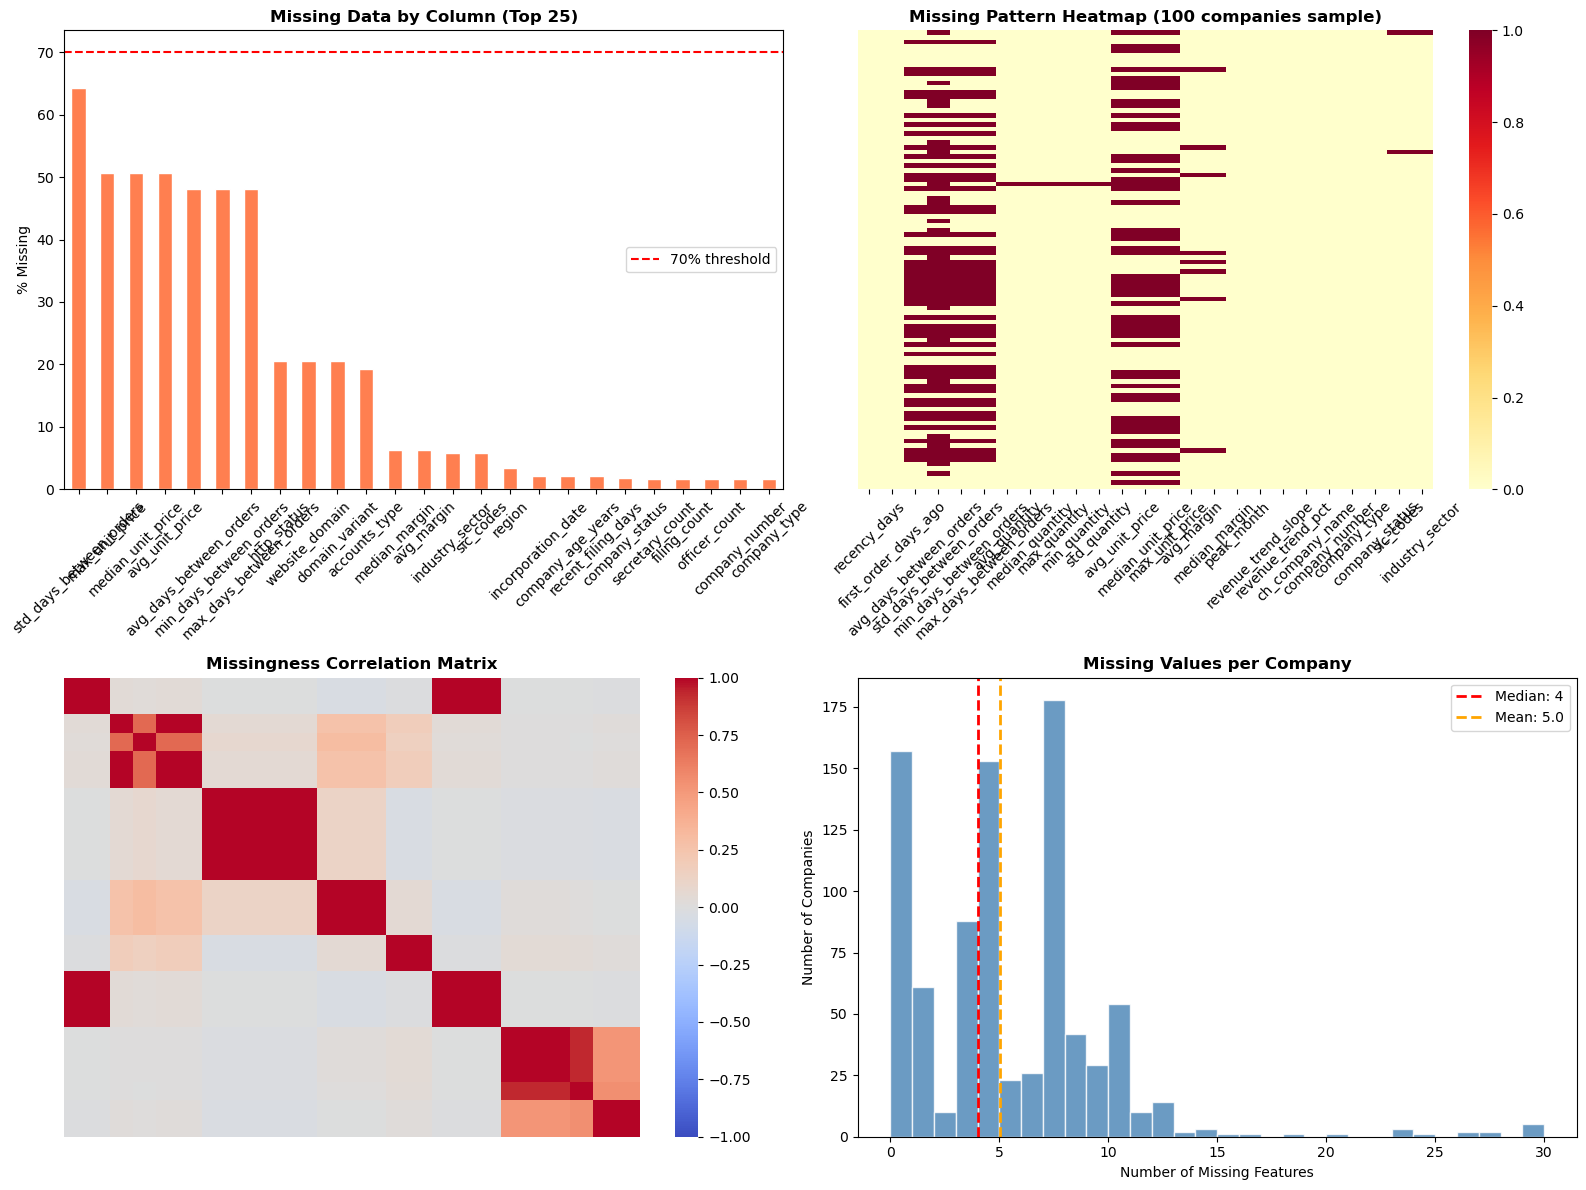

In [5]:
def plot_missing_patterns(df):
    """Visualize missing data patterns"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Bar chart of missing percentages
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    
    ax1 = axes[0, 0]
    if len(missing_pct) > 0:
        missing_pct.head(25).plot(kind='bar', ax=ax1, color='coral', edgecolor='white')
        ax1.set_title('Missing Data by Column (Top 25)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('% Missing')
        ax1.tick_params(axis='x', rotation=45)
        ax1.axhline(y=70, color='red', linestyle='--', label='70% threshold')
        ax1.legend()
    else:
        ax1.text(0.5, 0.5, 'No missing data!', ha='center', va='center', fontsize=14)
    
    # 2. Missing data heatmap (sample of columns)
    ax2 = axes[0, 1]
    cols_with_missing = df.columns[df.isnull().any()].tolist()[:25]
    if cols_with_missing:
        sample_df = df[cols_with_missing].sample(min(100, len(df)), random_state=42)
        sns.heatmap(sample_df.isnull(), cbar=True, ax=ax2, cmap='YlOrRd',
                    xticklabels=True, yticklabels=False)
        ax2.set_title('Missing Pattern Heatmap (100 companies sample)', fontsize=12, fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
    
    # 3. Correlation of missingness
    ax3 = axes[1, 0]
    if len(cols_with_missing) > 1:
        missing_corr = df[cols_with_missing].isnull().corr()
        sns.heatmap(missing_corr, cmap='coolwarm', center=0, ax=ax3,
                    xticklabels=False, yticklabels=False, vmin=-1, vmax=1)
        ax3.set_title('Missingness Correlation Matrix', fontsize=12, fontweight='bold')
    
    # 4. Distribution of missing values per row
    ax4 = axes[1, 1]
    missing_per_row = df.isnull().sum(axis=1)
    ax4.hist(missing_per_row, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax4.axvline(missing_per_row.median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: {missing_per_row.median():.0f}')
    ax4.axvline(missing_per_row.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean: {missing_per_row.mean():.1f}')
    ax4.set_title('Missing Values per Company', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Number of Missing Features')
    ax4.set_ylabel('Number of Companies')
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/missing_data_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return missing_pct

missing_pct = plot_missing_patterns(df)

In [6]:
# Identify missing data patterns
def identify_missing_patterns(df):
    """Identify groups of columns that are missing together"""
    
    cols_with_missing = df.columns[df.isnull().any()].tolist()
    if not cols_with_missing:
        print("No missing data found!")
        return None
    
    # Create missingness indicator matrix
    missing_matrix = df[cols_with_missing].isnull().astype(int)
    
    # Find unique missing patterns
    pattern_strings = missing_matrix.apply(lambda x: ''.join(x.astype(str)), axis=1)
    pattern_counts = pattern_strings.value_counts()
    
    print("=" * 70)
    print("MISSING DATA PATTERNS")
    print("=" * 70)
    print(f"Unique patterns: {len(pattern_counts)}")
    print(f"\nTop 10 patterns:")
    
    for i, (pattern, count) in enumerate(pattern_counts.head(10).items()):
        pct = count / len(df) * 100
        missing_cols = [col for col, val in zip(cols_with_missing, pattern) if val == '1']
        print(f"\nPattern {i+1}: {count} companies ({pct:.1f}%)")
        if missing_cols:
            print(f"  Missing: {missing_cols[:5]}{'...' if len(missing_cols) > 5 else ''}")
        else:
            print(f"  Complete rows (no missing in these columns)")
    
    return pattern_counts

patterns = identify_missing_patterns(df)

MISSING DATA PATTERNS
Unique patterns: 77

Top 10 patterns:

Pattern 1: 157 companies (18.1%)
  Complete rows (no missing in these columns)

Pattern 2: 138 companies (15.9%)
  Missing: ['avg_days_between_orders', 'std_days_between_orders', 'min_days_between_orders', 'max_days_between_orders', 'avg_unit_price']...

Pattern 3: 80 companies (9.2%)
  Missing: ['avg_days_between_orders', 'std_days_between_orders', 'min_days_between_orders', 'max_days_between_orders']

Pattern 4: 66 companies (7.6%)
  Missing: ['avg_unit_price', 'median_unit_price', 'max_unit_price']

Pattern 5: 45 companies (5.2%)
  Missing: ['avg_days_between_orders', 'std_days_between_orders', 'min_days_between_orders', 'max_days_between_orders', 'avg_unit_price']...

Pattern 6: 44 companies (5.1%)
  Missing: ['std_days_between_orders', 'avg_unit_price', 'median_unit_price', 'max_unit_price']

Pattern 7: 36 companies (4.2%)
  Missing: ['std_days_between_orders']

Pattern 8: 25 companies (2.9%)
  Missing: ['accounts_type']

## 3. Feature Classification

Classify features by type and source for targeted handling.

In [7]:
def classify_features(df):
    """Classify features by type and source"""
    
    feature_groups = {
        # Identifiers (exclude from ML)
        'identifiers': [],
        
        # Internal RFM features
        'internal_numerical': [],
        
        # Companies House numerical
        'ch_numerical': [],
        
        # Companies House categorical
        'ch_categorical': [],
        
        # Binary flags
        'binary': [],
        
        # Other
        'other': []
    }
    
    # Classification rules
    id_keywords = ['company', 'name', 'number', 'address', 'postcode', 'url']
    internal_keywords = ['recency', 'frequency', 'monetary', 'order', 'revenue', 
                         'product', 'complexity', 'rfm', 'ratio', 'tier', 'quintile',
                         'avg_', 'total_', 'unique_', 'first_', 'last_', 'days_']
    ch_num_keywords = ['age', 'officer', 'filing', 'overdue', 'charge', 'accounts',
                       'confirmation', 'psc', 'active_', 'resigned_']
    ch_cat_keywords = ['status', 'type', 'jurisdiction', 'sic', 'category']
    binary_keywords = ['has_', 'is_', 'matched', 'bool']
    
    for col in df.columns:
        col_lower = col.lower()
        dtype = df[col].dtype
        
        # Check identifiers first
        if any(kw in col_lower for kw in id_keywords) and dtype == 'object':
            feature_groups['identifiers'].append(col)
        elif any(kw in col_lower for kw in binary_keywords) or (dtype == 'float64' and df[col].dropna().isin([0, 1]).all()):
            feature_groups['binary'].append(col)
        elif any(kw in col_lower for kw in ch_cat_keywords) and dtype == 'object':
            feature_groups['ch_categorical'].append(col)
        elif any(kw in col_lower for kw in ch_num_keywords) and dtype in ['float64', 'int64']:
            feature_groups['ch_numerical'].append(col)
        elif any(kw in col_lower for kw in internal_keywords) and dtype in ['float64', 'int64']:
            feature_groups['internal_numerical'].append(col)
        elif dtype in ['float64', 'int64']:
            feature_groups['other'].append(col)
        elif dtype == 'object':
            feature_groups['ch_categorical'].append(col)
        else:
            feature_groups['other'].append(col)
    
    # Print summary
    print("=" * 70)
    print("FEATURE CLASSIFICATION")
    print("=" * 70)
    for group, cols in feature_groups.items():
        print(f"\n{group.upper()} ({len(cols)} features):")
        for col in cols[:10]:
            missing_pct = df[col].isnull().mean() * 100
            print(f"  - {col} ({missing_pct:.1f}% missing)")
        if len(cols) > 10:
            print(f"  ... and {len(cols) - 10} more")
    
    return feature_groups

feature_groups = classify_features(df)

FEATURE CLASSIFICATION

IDENTIFIERS (5 features):
  - company (0.0% missing)
  - ch_company_name (1.6% missing)
  - company_number (1.6% missing)
  - company_type (1.6% missing)
  - company_status (1.8% missing)

INTERNAL_NUMERICAL (28 features):
  - recency_days (0.1% missing)
  - first_order_days_ago (0.1% missing)
  - frequency (0.0% missing)
  - monetary_total (0.0% missing)
  - monetary_mean (0.0% missing)
  - monetary_median (0.0% missing)
  - monetary_std (0.0% missing)
  - monetary_max (0.0% missing)
  - monetary_min (0.0% missing)
  - avg_days_between_orders (48.1% missing)
  ... and 18 more

CH_NUMERICAL (8 features):
  - company_age_years (2.2% missing)
  - officer_count (1.6% missing)
  - active_officer_count (1.6% missing)
  - filing_count (1.6% missing)
  - recent_filing_days (2.2% missing)
  - annual_accounts_count (1.6% missing)
  - charge_count (1.6% missing)
  - psc_count (1.6% missing)

CH_CATEGORICAL (8 features):
  - sic_codes (5.8% missing)
  - industry_sector (5.

## 4. Data Preprocessing Pipeline

**Strategy (recommended by data scientist):**
1. **Categorical**: Fill with 'Unknown' category
2. **Numerical**: Median imputation + missing indicator columns
3. **Binary**: Domain-informed fill (usually 0)
4. Drop columns with >70% missing
5. Drop rows with >50% missing features

In [8]:
class CustomerSegmentationPreprocessor:
    """Complete preprocessing pipeline for customer segmentation"""
    
    def __init__(self, df, feature_groups):
        self.df_original = df.copy()
        self.df = df.copy()
        self.feature_groups = feature_groups
        self.preprocessing_log = []
        self.missing_indicator_cols = []
        
    def _log(self, message):
        self.preprocessing_log.append(message)
        print(message)
    
    def create_ch_matched_indicator(self):
        """Create indicator for Companies House data availability"""
        
        if 'ch_matched' not in self.df.columns:
            ch_cols = self.feature_groups.get('ch_numerical', []) + \
                      self.feature_groups.get('ch_categorical', [])
            
            if ch_cols:
                self.df['ch_matched'] = (~self.df[ch_cols].isnull().all(axis=1)).astype(int)
                self.feature_groups['binary'].append('ch_matched')
                ch_matched_pct = self.df['ch_matched'].mean() * 100
                self._log(f"Created ch_matched indicator: {ch_matched_pct:.1f}% matched")
        
        return self
    
    def handle_categorical(self):
        """Handle categorical missing values with 'Unknown' category"""
        
        self._log("\n--- Handling Categorical Features ---")
        
        for col in self.feature_groups.get('ch_categorical', []):
            if col in self.df.columns:
                missing_pct = self.df[col].isnull().mean() * 100
                
                if missing_pct > 0:
                    if self.df[col].dtype == 'object':
                        self.df[col] = self.df[col].fillna('Unknown')
                    else:
                        self.df[col] = self.df[col].fillna(-999)
                    
                    self._log(f"  {col}: {missing_pct:.1f}% -> 'Unknown'")
        
        return self
    
    def handle_numerical(self):
        """Handle numerical missing with median + indicator columns"""
        
        self._log("\n--- Handling Numerical Features (Median + Indicator) ---")
        
        numerical_cols = self.feature_groups.get('internal_numerical', []) + \
                         self.feature_groups.get('ch_numerical', []) + \
                         self.feature_groups.get('other', [])
        
        for col in numerical_cols:
            if col in self.df.columns and col not in self.feature_groups.get('identifiers', []):
                missing_pct = self.df[col].isnull().mean() * 100
                
                if missing_pct > 0:
                    # Create missing indicator
                    indicator_col = f'{col}_missing'
                    self.df[indicator_col] = self.df[col].isnull().astype(int)
                    self.missing_indicator_cols.append(indicator_col)
                    
                    # Impute with median
                    median_val = self.df[col].median()
                    self.df[col] = self.df[col].fillna(median_val)
                    
                    self._log(f"  {col}: {missing_pct:.1f}% missing, median={median_val:.2f}")
        
        return self
    
    def handle_binary(self):
        """Handle binary missing values"""
        
        self._log("\n--- Handling Binary Features ---")
        
        # Domain-specific fill values
        fill_rules = {
            'has_website': 0,
            'has_charges': 0,
            'has_insolvency_history': 0,
            'is_community_interest_company': 0,
            'has_been_liquidated': 0,
            'ch_matched': 0
        }
        
        for col in self.feature_groups.get('binary', []):
            if col in self.df.columns:
                missing_pct = self.df[col].isnull().mean() * 100
                
                if missing_pct > 0:
                    fill_val = fill_rules.get(col, 0)
                    self.df[col] = self.df[col].fillna(fill_val)
                    self._log(f"  {col}: {missing_pct:.1f}% -> {fill_val}")
        
        return self
    
    def drop_high_missing_columns(self, threshold=70):
        """Drop columns with >threshold% missing"""
        
        self._log(f"\n--- Dropping Columns with >{threshold}% Missing ---")
        
        missing_pct = self.df.isnull().mean() * 100
        high_missing = missing_pct[missing_pct > threshold].index.tolist()
        
        # Don't drop identifiers even if missing
        high_missing = [c for c in high_missing if c not in self.feature_groups.get('identifiers', [])]
        
        if high_missing:
            self._log(f"  Dropping {len(high_missing)} columns:")
            for col in high_missing:
                self._log(f"    - {col} ({missing_pct[col]:.1f}% missing)")
            self.df = self.df.drop(columns=high_missing, errors='ignore')
        else:
            self._log("  No columns to drop")
        
        return self
    
    def drop_low_quality_rows(self, threshold=50):
        """Drop rows with >threshold% missing features"""
        
        self._log(f"\n--- Dropping Rows with >{threshold}% Missing ---")
        
        # Calculate % missing per row
        missing_per_row = self.df.isnull().sum(axis=1)
        total_cols = len(self.df.columns)
        missing_pct_per_row = missing_per_row / total_cols * 100
        
        rows_to_drop = self.df[missing_pct_per_row > threshold].index
        
        if len(rows_to_drop) > 0:
            self._log(f"  Dropping {len(rows_to_drop)} rows")
            self.df = self.df.drop(index=rows_to_drop, errors='ignore')
        else:
            self._log("  No rows to drop")
        
        return self
    
    def verify_no_missing(self):
        """Verify no missing data remains in feature columns"""
        
        self._log("\n--- Verification ---")
        
        # Check non-identifier columns
        feature_cols = [c for c in self.df.columns if c not in self.feature_groups.get('identifiers', [])]
        remaining_missing = self.df[feature_cols].isnull().sum().sum()
        
        if remaining_missing > 0:
            self._log(f"  WARNING: {remaining_missing} missing values remain")
            missing_cols = self.df[feature_cols].columns[self.df[feature_cols].isnull().any()]
            for col in missing_cols:
                self._log(f"    - {col}: {self.df[col].isnull().sum()} missing")
        else:
            self._log("  SUCCESS: No missing values in feature columns")
        
        return self
    
    def run_pipeline(self):
        """Run complete preprocessing pipeline"""
        
        self._log("=" * 70)
        self._log("PREPROCESSING PIPELINE")
        self._log("=" * 70)
        self._log(f"Starting with {len(self.df)} companies, {len(self.df.columns)} features")
        
        return (self
                .create_ch_matched_indicator()
                .handle_categorical()
                .handle_numerical()
                .handle_binary()
                .drop_high_missing_columns(threshold=70)
                .drop_low_quality_rows(threshold=50)
                .verify_no_missing())
    
    def get_data(self):
        """Get processed data"""
        return {
            'df': self.df,
            'original': self.df_original,
            'log': self.preprocessing_log,
            'missing_indicators': self.missing_indicator_cols
        }

In [9]:
# Run the preprocessing pipeline
preprocessor = CustomerSegmentationPreprocessor(df, feature_groups)
preprocessor.run_pipeline()

# Get processed data
result = preprocessor.get_data()
df_processed = result['df']

print(f"\n" + "=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)
print(f"Original:  {len(df)} companies, {len(df.columns)} features")
print(f"Processed: {len(df_processed)} companies, {len(df_processed.columns)} features")
print(f"Missing indicator columns added: {len(result['missing_indicators'])}")

PREPROCESSING PIPELINE
Starting with 867 companies, 98 features
Created ch_matched indicator: 100.0% matched

--- Handling Categorical Features ---
  sic_codes: 5.8% -> 'Unknown'
  industry_sector: 5.8% -> 'Unknown'
  incorporation_date: 2.2% -> 'Unknown'
  region: 3.3% -> 'Unknown'
  accounts_type: 19.3% -> 'Unknown'
  website_domain: 20.5% -> 'Unknown'
  domain_variant: 20.5% -> 'Unknown'

--- Handling Numerical Features (Median + Indicator) ---
  recency_days: 0.1% missing, median=1183.50
  first_order_days_ago: 0.1% missing, median=1681.00
  avg_days_between_orders: 48.1% missing, median=43.25
  std_days_between_orders: 64.2% missing, median=84.76
  min_days_between_orders: 48.1% missing, median=0.00
  max_days_between_orders: 48.1% missing, median=170.00
  avg_quantity: 1.5% missing, median=500.00
  avg_unit_price: 50.6% missing, median=4.92
  avg_margin: 6.2% missing, median=20.00
  revenue_trend_slope: 0.1% missing, median=0.00
  revenue_trend_pct: 0.1% missing, median=0.00
  co

## 5. Prepare Feature Matrix for Clustering

In [10]:
def prepare_clustering_features(df, feature_groups):
    """Prepare feature matrix for clustering"""
    
    # Exclude identifiers
    exclude_cols = feature_groups.get('identifiers', [])
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    # Separate numerical and categorical
    numerical_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df[feature_cols].select_dtypes(include=['object']).columns.tolist()
    
    print(f"Numerical features: {len(numerical_features)}")
    print(f"Categorical features: {len(categorical_features)}")
    
    # Build preprocessing pipeline
    numerical_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop'
    )
    
    # Fit and transform
    X = preprocessor.fit_transform(df)
    
    # Get feature names
    cat_feature_names = []
    if categorical_features:
        cat_feature_names = preprocessor.named_transformers_['cat'] \
            .named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
    
    feature_names = numerical_features + cat_feature_names
    
    print(f"\nFinal feature matrix shape: {X.shape}")
    
    return X, feature_names, preprocessor

X, feature_names, sklearn_preprocessor = prepare_clustering_features(df_processed, feature_groups)

Numerical features: 110
Categorical features: 9

Final feature matrix shape: (867, 2181)


## 6. Final Dataset Summary

In [11]:
print("=" * 70)
print("FINAL PREPROCESSED DATASET")
print("=" * 70)
print(f"Companies:               {len(df_processed)}")
print(f"Raw features:            {len(df_processed.columns)}")
print(f"ML feature matrix:       {X.shape[0]} x {X.shape[1]}")
print(f"Missing values:          {np.isnan(X).sum()}")
print(f"\nFeature breakdown:")
print(f"  Numerical (scaled):    {len([f for f in feature_names if f in df_processed.columns])}")
print(f"  Missing indicators:    {len(result['missing_indicators'])}")
print(f"  Categorical (encoded): {len([f for f in feature_names if f not in df_processed.columns])}")

FINAL PREPROCESSED DATASET
Companies:               867
Raw features:            129
ML feature matrix:       867 x 2181
Missing values:          0

Feature breakdown:
  Numerical (scaled):    110
  Missing indicators:    30
  Categorical (encoded): 2071


In [12]:
# Save processed data
output_path = DATA_DIR / 'company_features_preprocessed.csv'
df_processed.to_csv(output_path, index=False)
print(f"Saved preprocessed data to: {output_path}")

# Save feature matrix as numpy array
np.save(DATA_DIR / 'X_clustering.npy', X)
print(f"Saved feature matrix to: {DATA_DIR / 'X_clustering.npy'}")

# Save feature names
import json
with open(DATA_DIR / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"Saved feature names to: {DATA_DIR / 'feature_names.json'}")

Saved preprocessed data to: ../data/companies/company_features_preprocessed.csv
Saved feature matrix to: ../data/companies/X_clustering.npy
Saved feature names to: ../data/companies/feature_names.json


## 7. Quick Clustering Test

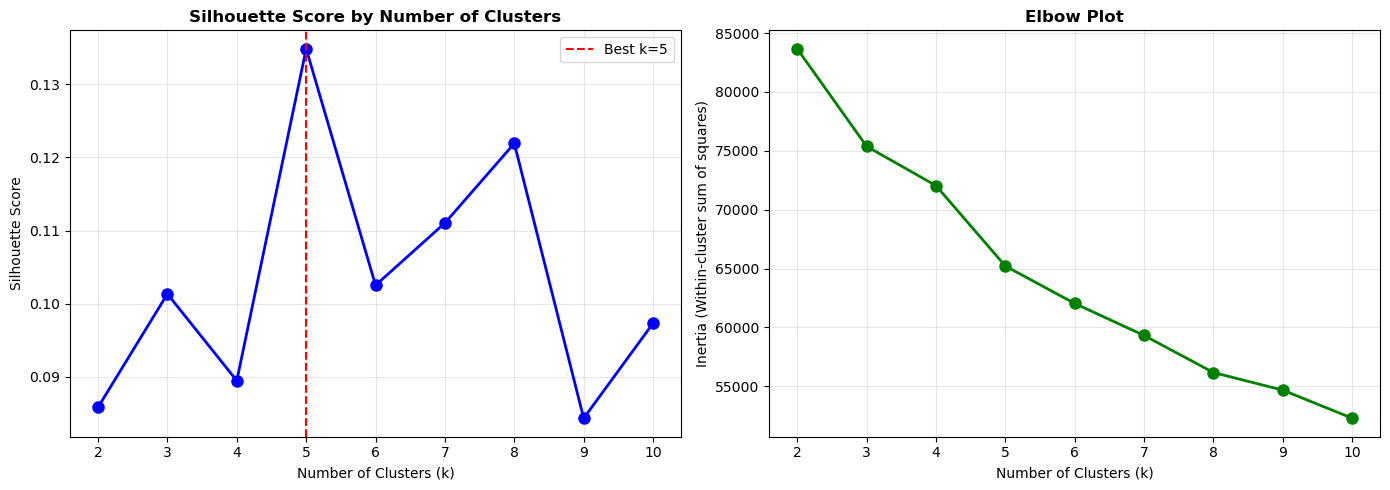


Best k by silhouette score: 5 (score: 0.135)


In [13]:
# Test clustering with different k values
k_range = range(2, 11)
silhouette_scores = []
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))
    inertias.append(kmeans.inertia_)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette scores
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score by Number of Clusters', fontweight='bold')
best_k = list(k_range)[np.argmax(silhouette_scores)]
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Elbow plot
axes[1].plot(k_range, inertias, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[1].set_title('Elbow Plot', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest k by silhouette score: {best_k} (score: {max(silhouette_scores):.3f})")

In [14]:
# Final clustering with best k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_processed['cluster'] = kmeans_final.fit_predict(X)

print("Cluster distribution:")
print(df_processed['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    330
1     14
2     13
3    486
4     24
Name: count, dtype: int64


## 8. Preprocessing Log

In [15]:
# Print full preprocessing log
print("FULL PREPROCESSING LOG")
print("=" * 70)
for line in result['log']:
    print(line)

FULL PREPROCESSING LOG
PREPROCESSING PIPELINE
Starting with 867 companies, 98 features
Created ch_matched indicator: 100.0% matched

--- Handling Categorical Features ---
  sic_codes: 5.8% -> 'Unknown'
  industry_sector: 5.8% -> 'Unknown'
  incorporation_date: 2.2% -> 'Unknown'
  region: 3.3% -> 'Unknown'
  accounts_type: 19.3% -> 'Unknown'
  website_domain: 20.5% -> 'Unknown'
  domain_variant: 20.5% -> 'Unknown'

--- Handling Numerical Features (Median + Indicator) ---
  recency_days: 0.1% missing, median=1183.50
  first_order_days_ago: 0.1% missing, median=1681.00
  avg_days_between_orders: 48.1% missing, median=43.25
  std_days_between_orders: 64.2% missing, median=84.76
  min_days_between_orders: 48.1% missing, median=0.00
  max_days_between_orders: 48.1% missing, median=170.00
  avg_quantity: 1.5% missing, median=500.00
  avg_unit_price: 50.6% missing, median=4.92
  avg_margin: 6.2% missing, median=20.00
  revenue_trend_slope: 0.1% missing, median=0.00
  revenue_trend_pct: 0.1% mi